In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
from tqdm import tqdm
import os
from PIL import Image
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
import numpy as np
from torchvision import datasets, transforms, models
import random
from sklearn.model_selection import train_test_split

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


image_list  = []

# This assumes that data is in 10 folders labelled from 0 to 10
for num in range(10):
    path = str(num)
    if os.path.exists(path):
        for file_name in os.listdir(path):
            file_path = os.path.join(path, file_name)
            img = Image.open(file_path).convert("L")
                
            image_list.append({
                'dir': file_path,
                'file_name': file_name,
                'image': img,
                'class': num
            })


Using device: cuda


In [20]:
class CustomImageListDataset(Dataset):
    def __init__(self, image_list, transform=None):
        self.image_list = image_list
        self.transform = transform

    def __len__(self):
        return len(self.image_list)

    def __getitem__(self, idx):
        img_data = self.image_list[idx]
        img = img_data['image']
        label = img_data['class']

        if self.transform:
            img = self.transform(img)

        return img, label

In [21]:

def get_dataloaders(image_list, split='SPLIT1', batch_size=64):
    
    assert split in ['SPLIT1', 'SPLIT2', 'SPLIT3'], "Invalid split type"

    mnist = datasets.MNIST(root='./data', train=True, download=True)
    subset_size = 5000
    indices = random.sample(range(len(mnist)), subset_size)

    mnist_subset = [mnist[i] for i in indices]
    
    mnist_list = []
    for img,label in mnist_subset:
        mnist_list.append({
            'image': img,
            'class': label
        })

    basic_transform = transforms.Compose([
        transforms.Resize((28, 28)),
        transforms.ToTensor()
    ])
    
    
    normalize_transform = transforms.Compose([
        transforms.Resize((28, 28)),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    
    # Disable testing for lab 3
    # __ , test_list =train_test_split(image_list, test_size=1) 
    # print(test_list)

    # Load data as is
    if split == 'SPLIT1':
        train_list, val_test_list = train_test_split(mnist_list, test_size=0.3)
        train_ds = CustomImageListDataset(train_list, transform=basic_transform)
        val_ds   = CustomImageListDataset(val_test_list, transform=basic_transform)
        # test_ds  = CustomImageListDataset(test_list, transform=basic_transform)


    # Load normalized data
    elif split == 'SPLIT2':
        train_list, val_test_list = train_test_split(mnist_list, test_size=0.3)
        train_ds = CustomImageListDataset(train_list, transform=normalize_transform)
        val_ds   = CustomImageListDataset(val_test_list, transform=normalize_transform)
        # test_ds  = CustomImageListDataset(test_list, transform=normalize_transform)

    # Load normalized data BUT val is subset of test
    elif split == 'SPLIT3':
        train_list, __ = train_test_split(mnist_list, test_size=0.3)
        val , test = train_test_split(train_list, test_size=0.3)

        train_ds = CustomImageListDataset(train_list, transform=normalize_transform)
        val_ds   = CustomImageListDataset(val, transform=normalize_transform)
        # test_ds  = CustomImageListDataset(test, transform=normalize_transform)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    # test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader#, test_loader

In [22]:
def get_model(pretrained=True):
    model = models.resnet18(weights="IMAGENET1K_V1" if pretrained else None)
    model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
    model.fc = nn.Linear(model.fc.in_features, 10)
    return model.to(device)


In [23]:
import time

def train(model, train_loader, val_loader, epochs=10, lr=0.001, model_name='0'):
    crossEntropyLoss = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    best_train_loss = 0
    best_val_acc = 0 
    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = crossEntropyLoss(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        train_loss = total_loss / len(train_loader)
        train_losses.append(train_loss)

        model.eval()
        val_loss = 0
        correct = 0
        total = 0

        # Validation
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                val_loss += crossEntropyLoss(outputs, labels).item()
                preds = outputs.argmax(1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
        val_loss /= len(val_loader)
        val_losses.append(val_loss)
        val_acc = correct / total * 100

        print(f"Epoch {epoch + 1} | Train Loss: {train_loss} | Val Loss: {val_loss} | Val Acc: {val_acc}%")

        if val_loss < best_val_loss:
            best_train_loss = train_loss
            best_val_acc = val_acc
            best_val_loss = val_loss
            torch.save(model.state_dict(), f'MODEL{model_name}.pth')

    end_time = time.time()

    print(f"Total time: {end_time - start_time}")
    print(f"Final Train Loss: {best_train_loss}")
    print(f"Final Val Loss: {best_val_loss}")
    print(f"Final Val Accuracy: {best_val_acc}%")

    return train_losses, val_losses

In [24]:
def visualize_loss(train_losses, val_losses):
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Train/Val loss')
    plt.legend()
    plt.show()

Epoch 1 | Train Loss: 0.719219514050267 | Val Loss: 0.3843472010145585 | Val Acc: 89.66666666666666%
Epoch 2 | Train Loss: 0.2698450318114324 | Val Loss: 0.26994835104172427 | Val Acc: 92.66666666666666%
Epoch 3 | Train Loss: 0.21178480545905504 | Val Loss: 0.20349167954797545 | Val Acc: 94.66666666666667%
Epoch 4 | Train Loss: 0.13651567297902975 | Val Loss: 0.17280892453466853 | Val Acc: 94.86666666666666%
Epoch 5 | Train Loss: 0.11989723979918794 | Val Loss: 0.21043145144358277 | Val Acc: 94.39999999999999%
Epoch 6 | Train Loss: 0.09377413069490682 | Val Loss: 0.20056306524202228 | Val Acc: 94.6%
Epoch 7 | Train Loss: 0.07743044766512784 | Val Loss: 0.20072654852022728 | Val Acc: 94.8%
Epoch 8 | Train Loss: 0.07568504099988124 | Val Loss: 0.19027762999758124 | Val Acc: 93.8%
Epoch 9 | Train Loss: 0.07680212593722073 | Val Loss: 0.1830943995155394 | Val Acc: 95.0%
Epoch 10 | Train Loss: 0.04531217887574299 | Val Loss: 0.1385714609544569 | Val Acc: 96.2%
Epoch 11 | Train Loss: 0.09066

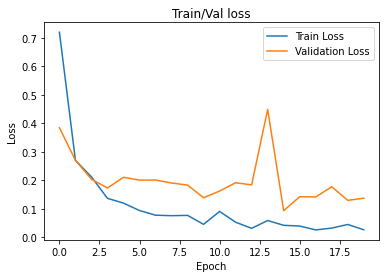

Epoch 1 | Train Loss: 0.7777862611142072 | Val Loss: 0.43179353202382725 | Val Acc: 86.86666666666667%
Epoch 2 | Train Loss: 0.29562291638417676 | Val Loss: 0.4378648598988851 | Val Acc: 87.6%
Epoch 3 | Train Loss: 0.18302375477823343 | Val Loss: 0.27195076644420624 | Val Acc: 92.06666666666666%
Epoch 4 | Train Loss: 0.15659843629056758 | Val Loss: 0.15512416853259006 | Val Acc: 96.13333333333334%
Epoch 5 | Train Loss: 0.12425726044245741 | Val Loss: 0.21871967365344366 | Val Acc: 93.66666666666667%
Epoch 6 | Train Loss: 0.10052452108568766 | Val Loss: 0.15323286006848016 | Val Acc: 94.93333333333334%
Epoch 7 | Train Loss: 0.08825598153793676 | Val Loss: 0.11227910853146265 | Val Acc: 97.06666666666666%
Epoch 8 | Train Loss: 0.08515220763669773 | Val Loss: 0.14487153512891382 | Val Acc: 96.0%
Epoch 9 | Train Loss: 0.07075731144286693 | Val Loss: 0.12187524725838254 | Val Acc: 96.73333333333333%
Epoch 10 | Train Loss: 0.0641123461325399 | Val Loss: 0.3407629053108394 | Val Acc: 91.8%
Ep

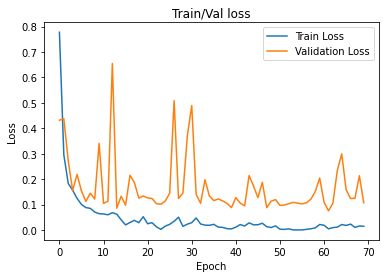

In [25]:

#SPLIT1
train_loader, val_loader = get_dataloaders(image_list, split='SPLIT1')
model_pretrained = get_model(pretrained=True)

train_losses, val_losses = train(model_pretrained, train_loader, val_loader, epochs=20, model_name="1")
visualize_loss(train_losses, val_losses)

#SPLIT1 overfit
train_loader, val_loader = get_dataloaders(image_list, split='SPLIT1')
model_pretrained = get_model(pretrained=True)

train_losses, val_losses = train(model_pretrained, train_loader, val_loader, epochs=70, model_name="1")
visualize_loss(train_losses, val_losses)

Epoch 1 | Train Loss: 0.8343466341495513 | Val Loss: 0.3119924869388342 | Val Acc: 91.4%
Epoch 2 | Train Loss: 0.30488715984604575 | Val Loss: 0.760701217999061 | Val Acc: 78.46666666666667%
Epoch 3 | Train Loss: 0.2689504474401474 | Val Loss: 0.2736056794722875 | Val Acc: 91.0%
Epoch 4 | Train Loss: 0.1546911307695237 | Val Loss: 0.4550203674783309 | Val Acc: 87.73333333333333%
Epoch 5 | Train Loss: 0.16603797335516324 | Val Loss: 0.25476155973350006 | Val Acc: 92.80000000000001%
Epoch 6 | Train Loss: 0.10060886295342987 | Val Loss: 0.18691144293795028 | Val Acc: 94.86666666666666%
Epoch 7 | Train Loss: 0.12394485209475864 | Val Loss: 0.1816874978442987 | Val Acc: 94.93333333333334%
Epoch 8 | Train Loss: 0.11411681534214453 | Val Loss: 0.23318901285529137 | Val Acc: 93.53333333333333%
Epoch 9 | Train Loss: 0.0876303818584843 | Val Loss: 0.23290224792435765 | Val Acc: 94.0%
Epoch 10 | Train Loss: 0.08947134271941402 | Val Loss: 0.26735907327383757 | Val Acc: 92.33333333333333%
Epoch 11

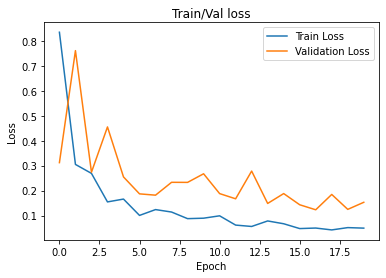

In [26]:

# SPLIT2
train_loader, val_loader = get_dataloaders(image_list, split='SPLIT2')
model_pretrained = get_model(pretrained=True)

train_losses, val_losses = train(model_pretrained, train_loader, val_loader, epochs=20, model_name="2")
visualize_loss(train_losses, val_losses)

Epoch 1 | Train Loss: 0.8213840636340055 | Val Loss: 0.38097182298317933 | Val Acc: 89.14285714285714%
Epoch 2 | Train Loss: 0.28973890949379316 | Val Loss: 0.19926173220842314 | Val Acc: 94.28571428571428%
Epoch 3 | Train Loss: 0.23543972291729667 | Val Loss: 0.13285367334118256 | Val Acc: 96.08163265306122%
Epoch 4 | Train Loss: 0.18295931511304594 | Val Loss: 0.15365114980019057 | Val Acc: 95.22448979591836%
Epoch 5 | Train Loss: 0.17000276883217422 | Val Loss: 0.09560519430595331 | Val Acc: 97.14285714285714%
Epoch 6 | Train Loss: 0.13597883363677696 | Val Loss: 0.08091178765066732 | Val Acc: 97.34693877551021%
Epoch 7 | Train Loss: 0.1004084065895189 | Val Loss: 0.05619085795031144 | Val Acc: 98.24489795918367%
Epoch 8 | Train Loss: 0.09684823455966332 | Val Loss: 0.05393119912164716 | Val Acc: 98.3265306122449%
Epoch 9 | Train Loss: 0.12463933734053916 | Val Loss: 0.16944204175319427 | Val Acc: 95.71428571428572%
Epoch 10 | Train Loss: 0.08694713312116537 | Val Loss: 0.0708772458

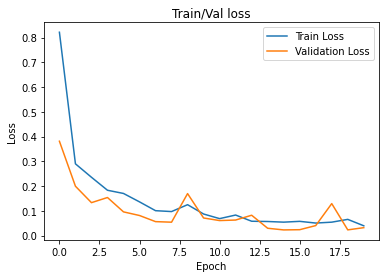

In [27]:

#SPLIT3
train_loader, val_loader = get_dataloaders(image_list, split='SPLIT3')
model_pretrained = get_model(pretrained=True)

train_losses, val_losses = train(model_pretrained, train_loader, val_loader, epochs=20, model_name="3")
visualize_loss(train_losses, val_losses)